In [0]:
%load_ext autoreload
%autoreload 2
# Enables autoreload; learn more at https://docs.databricks.com/en/files/workspace-modules.html#autoreload-for-python-modules
# To disable autoreload; run %autoreload 0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [0]:
%pip install -U \
  mlflow \
  langchain \
  langchain-core \
  langchain-openai \
  langgraph \
  databricks-langchain \
  databricks-vectorsearch \
  databricks-sdk \
  langchain-mcp-adapters \
  mcp \
  openai \
  python-dotenv

INFO: pip is looking at multiple versions of unitycatalog-openai to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of unitycatalog-openai[databricks] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.8/604.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88

In [0]:
dbutils.library.restartPython()

In [0]:
import os
import sys

PROJECT_ROOT = (
    "/Workspace/Users/"
    "talhaimran0270@gmail.com/pa4"
)

os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [0]:
# TODO(0.1): load config / verify env vars
# from config import ...

import os
from dotenv import load_dotenv

load_dotenv()

REQUIRED_ENV_VARS = [
    "DATABRICKS_HOST",
    "DATABRICKS_TOKEN",
    "DATABRICKS_MODEL",
    "EMBEDDINGS_ENDPOINT",
    "UC_CATALOG",
    "UC_SCHEMA",
    "VECTOR_SEARCH_ENDPOINT",
    "VECTOR_SEARCH_INDEX",
]

missing = [name for name in REQUIRED_ENV_VARS if not os.getenv(name)]

if missing:
    raise EnvironmentError(
        "Missing required environment variables: "
        + ", ".join(missing)
    )

print("Environment configuration loaded successfully.")
print("Databricks host:", os.getenv("DATABRICKS_HOST"))
print("LLM endpoint:", os.getenv("DATABRICKS_MODEL"))
print("Embedding endpoint:", os.getenv("EMBEDDINGS_ENDPOINT"))
print("UC catalog:", os.getenv("UC_CATALOG"))
print("UC schema:", os.getenv("UC_SCHEMA"))
print("Vector Search endpoint:", os.getenv("VECTOR_SEARCH_ENDPOINT"))
print("Vector Search index:", os.getenv("VECTOR_SEARCH_INDEX"))

# Never print the actual token
print("Databricks token configured:", bool(os.getenv("DATABRICKS_TOKEN")))


Environment configuration loaded successfully.
Databricks host: https://dbc-41f02e7c-e644.cloud.databricks.com
LLM endpoint: databricks-meta-llama-3-3-70b-instruct
Embedding endpoint: databricks-gte-large-en
UC catalog: main
UC schema: default
Vector Search endpoint: talha-vs-endpoint
Vector Search index: main.default.talha_analyst_index
Databricks token configured: True


In [0]:
import os
import sys
import importlib

PROJECT_ROOT = "/Workspace/Users/talhaimran0270@gmail.com/pa4"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

importlib.invalidate_caches()

print("Project root:", PROJECT_ROOT)
print("Project root in sys.path:", PROJECT_ROOT in sys.path)
print("rag folder exists:", os.path.isdir(f"{PROJECT_ROOT}/rag"))
print("rag contents:", os.listdir(f"{PROJECT_ROOT}/rag"))

Project root: /Workspace/Users/talhaimran0270@gmail.com/pa4
Project root in sys.path: True
rag folder exists: True
rag contents: ['__init__.py', 'store.py', 'ingest.py']


In [0]:
dbutils.library.restartPython()

In [0]:
import os

CATALOG = os.environ.get("UC_CATALOG", "main")
SCHEMA = os.environ.get("UC_SCHEMA", "default")

VOLUME = "pa4"
VOLUME_DIRECTORY = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}"

PARSE_TABLE = f"{CATALOG}.{SCHEMA}.pa4_parsed_documents"
CHUNKS_TABLE = f"{CATALOG}.{SCHEMA}.pa4_chunks"

VECTOR_SEARCH_ENDPOINT = os.environ["VECTOR_SEARCH_ENDPOINT"]
VECTOR_SEARCH_INDEX = os.environ["VECTOR_SEARCH_INDEX"]
EMBEDDINGS_ENDPOINT = os.environ["EMBEDDINGS_ENDPOINT"]

spark.sql(f"CREATE CATALOG IF NOT EXISTS {CATALOG}")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}")
spark.sql(f"CREATE VOLUME IF NOT EXISTS {CATALOG}.{SCHEMA}.{VOLUME}")

print("Volume directory:", VOLUME_DIRECTORY)
print("Parse table:", PARSE_TABLE)
print("Chunks table:", CHUNKS_TABLE)

Volume directory: /Volumes/main/default/pa4
Parse table: main.default.pa4_parsed_documents
Chunks table: main.default.pa4_chunks


In [0]:
import os

notebook_dir = os.getcwd()
data_dir = os.path.join(notebook_dir, "data")

pdf_files = [
    file_name
    for file_name in os.listdir(data_dir)
    if file_name.lower().endswith(".pdf")
]

if not pdf_files:
    raise FileNotFoundError(
        f"No PDF files found in {data_dir}"
    )

for pdf_name in pdf_files:
    source_path = os.path.join(data_dir, pdf_name)
    destination_path = f"{VOLUME_DIRECTORY}/{pdf_name}"

    dbutils.fs.cp(
        f"file:{source_path}",
        destination_path,
        recurse=False,
    )

    print(f"Uploaded: {pdf_name}")
    print(f"Destination: {destination_path}")

print("\nUpload complete.")

Uploaded: annual_report.pdf
Destination: /Volumes/main/default/pa4/annual_report.pdf

Upload complete.


In [0]:
import importlib
import rag.ingest

importlib.reload(rag.ingest)

from rag.ingest import create_index

In [0]:
# TODO(0.3): ingest corpus -> Delta table -> Vector Search index; wait until READY
# from rag.ingest import ingest
# ingest(spark, volume_path='/Volumes/main/default/pa4/annual_report.pdf')

import os
import sys

# Add the pa4 directory to sys.path so we can import the rag module
pa4_dir = "/Workspace/Users/talhaimran0270@gmail.com/pa4"
if pa4_dir not in sys.path:
    sys.path.insert(0, pa4_dir)

from rag.ingest import (
    build_chunks_table,
    create_index,
    test_similarity_search,
)

CATALOG = os.environ.get("UC_CATALOG", "main")
SCHEMA = os.environ.get("UC_SCHEMA", "default")

VOLUME_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/pa4/annual_report.pdf"
CHUNKS_TABLE = f"{CATALOG}.{SCHEMA}.pa4_chunks"

build_chunks_table(
    spark=spark,
    volume_path=VOLUME_PATH,
    chunks_table=CHUNKS_TABLE,
)

index = create_index(chunks_table=CHUNKS_TABLE)

search_result = test_similarity_search(
    index=index,
    query="What was Meridian's net revenue in fiscal year 2023?",
)

Starting PA4 corpus ingestion
Source path:  /Volumes/main/default/pa4/annual_report.pdf
Parsed table: main.default.pa4_parsed_documents
Chunks table: main.default.pa4_chunks
Parsing documents with ai_parse_document...
Successfully parsed 1 document(s).
Generating searchable chunks with ai_prep_search...
Successfully created 7 chunk(s).

Chunk preview:
+----------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------+-------+
|chunk_id                          |chunk_preview                                                                                                                                                                                                  |source           |page   |
+----------------------------------+--------------------------------------------------------------------

In [0]:
from databricks.vector_search.client import VectorSearchClient
import os

vsc = VectorSearchClient(
    workspace_url=os.environ["DATABRICKS_HOST"],
    personal_access_token=os.environ["DATABRICKS_TOKEN"],
    disable_notice=True,
)

print("ENDPOINT STATUS")
print(
    vsc.get_endpoint(
        name="talha-vs-endpoint"
    )
)

index = vsc.get_index(
    endpoint_name="talha-vs-endpoint",
    index_name="main.default.talha_analyst_index",
)

print("\nINDEX STATUS")
print(index.describe().get("status"))

ENDPOINT STATUS
{'name': 'talha-vs-endpoint', 'creator': 'talhaimran0270@gmail.com', 'creation_timestamp': 1784383659194, 'last_updated_timestamp': 1784383659194, 'endpoint_type': 'STANDARD', 'last_updated_user': 'talhaimran0270@gmail.com', 'id': '7e346a77-7c74-4f3d-8d29-6d541b415722', 'endpoint_status': {'state': 'ONLINE'}, 'num_indexes': 1, 'throughput_info': {'requested_concurrency': 2.0, 'current_concurrency': 2.0, 'current_concurrency_utilization_percentage': 11.0, 'change_request_state': 'CHANGE_SUCCESS', 'requested_num_replicas': 1, 'current_num_replicas': 1}}

INDEX STATUS
{'detailed_state': 'ONLINE_TRIGGERED_UPDATE', 'message': 'Index creation succeeded. Check latest status: https://dbc-41f02e7c-e644.cloud.databricks.com/explore/data/main/default/talha_analyst_index', 'indexed_row_count': 7, 'triggered_update_status': {'last_processed_commit_version': 4, 'last_processed_commit_timestamp': '2026-07-18T14:12:34Z', 'triggered_update_progress': {'latest_version_currently_processin

## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [0]:
import os
import tempfile
from contextlib import asynccontextmanager
from pathlib import Path

import mcp.client.stdio as mcp_stdio
import langchain_mcp_adapters.sessions as mcp_sessions


_original_stdio_client = mcp_stdio.stdio_client

MCP_LOG_PATH = (
    Path(tempfile.gettempdir())
    / "pa4_mcp_subprocess.log"
)


@asynccontextmanager
async def notebook_safe_stdio_client(server_params, errlog=None):
    """
    Preserve the real MCP stdio transport while explicitly giving
    the Windows child process a file with a valid fileno().
    """

    with open(
        MCP_LOG_PATH,
        "a",
        encoding="utf-8",
        buffering=1,
    ) as real_error_log:

        async with _original_stdio_client(
            server_params,
            errlog=real_error_log,
        ) as streams:
            yield streams


# Patch both references because langchain-mcp-adapters may have
# imported stdio_client into its own module namespace.
mcp_stdio.stdio_client = notebook_safe_stdio_client
mcp_sessions.stdio_client = notebook_safe_stdio_client

print("Notebook-safe MCP stdio patch applied.")
print("MCP stderr log:", MCP_LOG_PATH)

Notebook-safe MCP stdio patch applied.
MCP stderr log: /tmp/pa4_mcp_subprocess.log


In [0]:
# TODO(1.7): build the compiled graph
# from agent.graph import build_graph
# graph = build_graph()

import importlib
import agent.graph

importlib.reload(agent.graph)

from agent.graph import build_graph

graph = build_graph()

print("Graph compiled successfully.")


Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: C:\Users\Talha\AppData\Local\Temp\pa4_mcp_server.log
Graph compiled successfully.


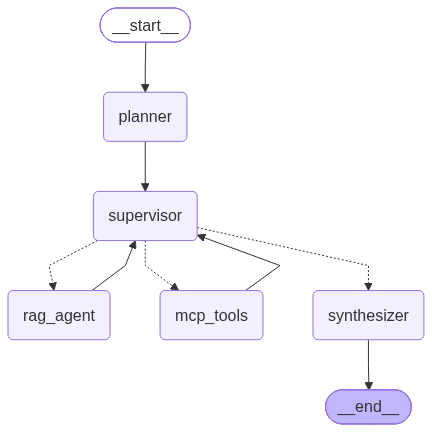

In [0]:
# TODO(1.7): visualize the compiled graph
# from IPython.display import Image
# Image(graph.get_graph().draw_mermaid_png())

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

### Test the graph


In [0]:
# Retrieval-only query
graph.invoke({'messages':[{'role':'user','content':'What was the net income in 2023?'}]})



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What was the net income in 2023?', additional_kwargs={}, response_metadata={}, id='5767ea08-51c8-474b-851d-29f82e187a5e'),
  AIMessage(content="The net income in 2023 was ¥1,107 billion, as reported in the company's annual report [source: annual_report.pdf].", additional_kwargs={}, response_metadata={}, id='0eebfe6b-5b3c-4928-832d-94f34f2ded0d', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['DOCUMENT RETRIEVAL: Find the net income of the company for the fiscal year 2023 in the financial document'],
 'current_step_index': 1,
 'step_results': ['Net income for the fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown].'],
 'next_agent': 'synthesizer',
 'final_answer': "The net income in 2023 was ¥1,107 billion, as reported in the company's annual report [source: annual_report.pdf]."}

In [0]:
# Computation-only query
graph.invoke({'messages':[{'role':'user','content':'What is 15% of 2.4 billion?'}]})



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What is 15% of 2.4 billion?', additional_kwargs={}, response_metadata={}, id='cd2b70c9-8afc-4709-b516-97ded59de71b'),
  AIMessage(content='To find 15% of 2.4 billion, we first acknowledge that the value 2.4 billion was not found in the documents, but we will use it as given for the calculation. \n\nThe calculation for 15% of 2.4 billion is done by multiplying 2.4 billion by 0.15 (which represents 15%). The formula is: 0.15 * 2.4e9. \n\nUsing this formula, we find that 15% of 2.4 billion is 0.15 * 2.4e9 = 3.6e+08, or 360 million.', additional_kwargs={}, response_metadata={}, id='eccfbcf8-c2d6-4a63-8fd3-6363b19bf33d', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Retrieve the value 2.4 billion',
  'Calculate 15 percent of 2.4 billion'],
 'current_step_index': 2,
 'step_results': ['not found in documents', '0.15 * 2.4e9 = 3.6e+08'],
 'next_agent': 'synthesizer',
 'final_answer': 'To find 15% of 2.4 billion, we first acknowledge that the value 2.4 b

In [0]:
# Combined query — show the full step-by-step execution trace
graph.invoke({'messages':[{'role':'user','content':'What was the revenue in 2023, and what would a 10% increase look like?'}]})



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What was the revenue in 2023, and what would a 10% increase look like?', additional_kwargs={}, response_metadata={}, id='28705fc0-29f0-4c4c-a191-3f715890cad8'),
  AIMessage(content='The revenue in 2023 was ¥16,910 billion, as reported in the annual report [source: annual_report.pdf]. A 10% increase would be calculated as follows: ¥16,910 * 1.10 = ¥18,601. This represents a potential increase of ¥1,691 billion.', additional_kwargs={}, response_metadata={}, id='808e787b-f9d3-4c5e-aa73-b979d50d7802', tool_calls=[], invalid_tool_calls=[])],
 'plan': ["DOCUMENT RETRIEVAL: Find the company's fiscal year 2023 net revenue",
  'CALCULATION: Calculate a 10% increase of the 2023 net revenue obtained in the previous step'],
 'current_step_index': 2,
 'step_results': ['¥16,910 billion [source: annual_report.pdf, p.unknown]',
  '16910 * 1.10 = 18601'],
 'next_agent': 'synthesizer',
 'final_answer': 'The revenue in 2023 was ¥16,910 billion, as reported in the annua

### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [0]:
!python -m pytest tests/test_smoke.py -q


..                                                                       [100%]


## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [0]:
# TODO(2.1): sanity-check the model definition imports cleanly
!python -c "import deployment.agent_model"



Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: C:\Users\Talha\AppData\Local\Temp\pa4_mcp_server.log


Processing request of type ListToolsRequest


In [0]:
# TODO(2.2): log + register the model version in Unity Catalog

from deployment.deploy import log_and_register

UC_MODEL_NAME, MODEL_VERSION = log_and_register()

print("\nTask 2.2 completed")
print(f"Registered model: {UC_MODEL_NAME}")
print(f"Registered version: {MODEL_VERSION}")

d:\Agentic-PA4\cs4603-pa4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


Logging Document Analyst
Experiment:    /Shared/pa4-document-analyst
Model file:    D:\Agentic-PA4\cs4603-pa4\deployment\agent_model.py
UC model name: main.default.pa4_document_analyst


2026/07/19 09:16:09 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in D:\Agentic-PA4\cs4603-pa4


Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: C:\Users\Talha\AppData\Local\Temp\pa4_mcp_server.log
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


d:\Agentic-PA4\cs4603-pa4\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/19 09:16:37 INFO mlflow: Attempting to auto-detect Databricks resource dependencies for the current langchain model. Dependency auto-detection is best-effort and may not capture all dependencies of your langchain model, resulting 

Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: C:\Users\Talha\AppData\Local\Temp\pa4_mcp_server.log
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/07/19 09:16:56 INFO mlflow.models.model: Found the following environment variables used during model inference: [DATABRICKS_HOST, DATABRICKS_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


🏃 View run pa4-document-analyst at: https://dbc-41f02e7c-e644.cloud.databricks.com/ml/experiments/2541659682872634/runs/224be80484ee4841bd49652443343f6e
🧪 View experiment at: https://dbc-41f02e7c-e644.cloud.databricks.com/ml/experiments/2541659682872634
MLflow run ID:   224be80484ee4841bd49652443343f6e
Logged model URI: models:/m-6bd240eac8734a1ba12c1a331b6a5eaa


Registered model 'main.default.pa4_document_analyst' already exists. Creating a new version of this model...
Uploading artifacts: 100%|██████████| 23/23 [00:14<00:00,  1.62it/s]
Created version '7' of model 'main.default.pa4_document_analyst'.


Model registered successfully
Registered model: main.default.pa4_document_analyst
Registered version: 7

Task 2.2 completed
Registered model: main.default.pa4_document_analyst
Registered version: 7


In [0]:
print("UC model:", UC_MODEL_NAME)
print("Model version:", MODEL_VERSION)

UC model: main.default.pa4_document_analyst
Model version: 6


In [0]:
from agent.graph import load_mcp_tools

tools = load_mcp_tools()

print([tool.name for tool in tools])

Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: /tmp/pa4_mcp_server.log
['calculate', 'percentage_change', 'growth_rate', 'compare_values', 'unit_convert']


In [0]:
import deployment.agent_model

print("agent_model imported successfully")

Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: /tmp/pa4_mcp_server.log
agent_model imported successfully


In [0]:
import os
import mlflow

# Change this to your actual Databricks workspace repository path.
PROJECT_ROOT = "/Workspace/Users/talhaimran0270@gmail.com/pa4"

os.chdir(PROJECT_ROOT)

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks-uc")
mlflow.set_experiment("/Shared/pa4-document-analyst")

PIP_REQUIREMENTS = [
    "mlflow",
    "langgraph",
    "langchain",
    "langchain-core",
    "langchain-openai",
    "databricks-langchain",
    "databricks-vectorsearch",
    "databricks-sdk",
    "langchain-mcp-adapters",
    "mcp",
    "openai",
    "python-dotenv",
]

input_example = {
    "messages": [
        {
            "role": "user",
            "content": (
                "What was Meridian's revenue in 2023, and what would "
                "it be after a 10 percent increase?"
            ),
        }
    ]
}

with mlflow.start_run(
    run_name="pa4-document-analyst"
):
    model_info = mlflow.langchain.log_model(
        lc_model="deployment/agent_model.py",
        name="agent",
        code_paths=[
            "agent",
            "rag",
            "tools",
            "config.py",
        ],
        pip_requirements=PIP_REQUIREMENTS,
        input_example=input_example,
    )

registered = mlflow.register_model(
    model_uri=model_info.model_uri,
    name="main.default.pa4_document_analyst",
)

UC_MODEL_NAME = "main.default.pa4_document_analyst"
MODEL_VERSION = str(registered.version)

print("UC model:", UC_MODEL_NAME)
print("New version:", MODEL_VERSION)

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
🔗 View Logged Model at: https://dbc-41f02e7c-e644.cloud.databricks.com/ml/experiments/2541659682872634/models/m-a49445251aca4ea48d9b66ed8a9287bc?o=7474657219940888


Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: /tmp/pa4_mcp_server.log
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


/local_disk0/.ephemeral_nfs/envs/pythonEnv-4cad0877-34f4-406e-9136-936dac3d455e/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/19 07:52:18 INFO mlflow: Attempting to auto-detect Databricks resource dependencies for the current langchain model. Dependency auto-detection is best-effort and may not c

Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: /tmp/pa4_mcp_server.log
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/07/19 07:52:26 INFO mlflow.models.model: Found the following environment variables used during model inference: [DATABRICKS_HOST, DATABRICKS_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.
Registered model 'main.default.pa4_document_analyst' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/28 [00:00<?, ?it/s]

🔗 Created version '10' of model 'main.default.pa4_document_analyst': https://dbc-41f02e7c-e644.cloud.databricks.com/explore/data/models/main/default/pa4_document_analyst/version/10?o=7474657219940888


UC model: main.default.pa4_document_analyst
New version: 10


In [0]:
# TODO(2.3): create/update the serving endpoint; wait for READY; print the URL
from deployment.deploy import create_or_update_endpoint

ENDPOINT_URL = create_or_update_endpoint(
    UC_MODEL_NAME,
    MODEL_VERSION,
)

SERVING_ENDPOINT_NAME = "talha-document-analyst"

print("\nTask 2.3 completed")
print(f"Endpoint name: {SERVING_ENDPOINT_NAME}")
print(f"Endpoint URL:  {ENDPOINT_URL}")


Deploying Document Analyst endpoint
Endpoint name: talha-document-analyst
UC model:      main.default.pa4_document_analyst
Model version: 10
Endpoint already exists.
Updating endpoint to main.default.pa4_document_analyst version 10...
Endpoint update request submitted.
Endpoint status after 0s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 20s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 40s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 60s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 80s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 100s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 120s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 140s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 160s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 180s: ready=NOT_READY, config_update=IN_PROGRESS
Endpoint status after 200s

### Test the deployed endpoint (Task 2.4)


In [0]:
import os
import time
import json
import subprocess
import openai
import requests

DATABRICKS_HOST = os.environ["DATABRICKS_HOST"].rstrip("/")
DATABRICKS_TOKEN = os.environ["DATABRICKS_TOKEN"]

ENDPOINT_NAME = "talha-document-analyst"

INVOCATION_URL = (
    f"{DATABRICKS_HOST}/serving-endpoints/"
    f"{ENDPOINT_NAME}/invocations"
)

print("Endpoint:", ENDPOINT_NAME)
print("URL:", INVOCATION_URL)

Endpoint: talha-document-analyst
URL: https://dbc-41f02e7c-e644.cloud.databricks.com/serving-endpoints/talha-document-analyst/invocations


In [0]:
# curl the endpoint and show the raw response

import json
import os
import subprocess
from dotenv import load_dotenv

load_dotenv()

DATABRICKS_HOST = os.environ["DATABRICKS_HOST"].rstrip("/")
DATABRICKS_TOKEN = os.environ["DATABRICKS_TOKEN"]
SERVING_ENDPOINT_NAME = os.environ["SERVING_ENDPOINT_NAME"]

ENDPOINT_URL = (
    f"{DATABRICKS_HOST}/serving-endpoints/"
    f"{SERVING_ENDPOINT_NAME}/invocations"
)

curl_payload = {
    "messages": [
        {
            "role": "user",
            "content": "What was the net income in 2023?",
        }
    ]
}

command = [
    "curl",
    "-sS",
    "-X",
    "POST",
    ENDPOINT_URL,
    "-H",
    f"Authorization: Bearer {DATABRICKS_TOKEN}",
    "-H",
    "Content-Type: application/json",
    "-d",
    json.dumps(curl_payload),
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True,
)

print("Endpoint:", ENDPOINT_URL)
print("curl return code:", result.returncode)

if result.stderr:
    print("\nSTDERR:")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("curl request failed.")

print("\nRaw endpoint response:")
try:
    raw_curl_response = json.loads(result.stdout)
    print(json.dumps(raw_curl_response, indent=2))
except json.JSONDecodeError:
    print(result.stdout)

Endpoint: https://dbc-41f02e7c-e644.cloud.databricks.com/serving-endpoints/talha-document-analyst/invocations
curl return code: 0

Raw endpoint response:
[
  {
    "messages": [
      {
        "content": "What was the net income in 2023?",
        "additional_kwargs": {},
        "response_metadata": {},
        "type": "human",
        "name": null,
        "id": "67c03efc-9cf8-40d3-b4e8-af671254ffdf"
      },
      {
        "content": "The net income for the fiscal year 2023 was \u00a51,107 billion [source: annual_report.pdf, p.unknown].",
        "additional_kwargs": {},
        "response_metadata": {},
        "type": "ai",
        "name": null,
        "id": "53dfacef-bec6-497d-abf5-3783bc3aaaf2",
        "tool_calls": [],
        "invalid_tool_calls": [],
        "usage_metadata": null
      }
    ],
    "plan": [
      "What was the net income in 2023?"
    ],
    "current_step_index": 1,
    "step_results": [
      "The net income for the fiscal year 2023 was \u00a51,107 bill

In [0]:
client = openai.OpenAI(
    api_key=DATABRICKS_TOKEN,
    base_url=f"{DATABRICKS_HOST}/serving-endpoints",
    timeout=180.0,
)

response = client.chat.completions.create(
    model=ENDPOINT_NAME,
    messages=[
        {
            "role": "user",
            "content": "What was the net income in 2023?",
        }
    ],
)

print("Raw SDK response:")
print(response)

Raw SDK response:
[ChatCompletion(id=None, choices=None, created=None, model=None, object=None, moderation=None, service_tier=None, system_fingerprint=None, usage=None, messages=[{'content': 'What was the net income in 2023?', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '8a4e3440-1f7e-4874-a1e0-edfec729ef28'}, {'content': 'The net income for the fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown].', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'name': None, 'id': '5debaa27-15bd-4e06-ba92-b4a509367231', 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': None}], plan=['What was the net income in 2023?'], current_step_index=1, step_results=['The net income for the fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown].'], next_agent='synthesizer', final_answer='The net income for the fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown].')]


In [0]:
def parse_sdk_response(response) -> str:
    data = (
        response.model_dump()
        if hasattr(response, "model_dump")
        else response
    )

    if isinstance(data, dict):
        choices = data.get("choices")

        if choices:
            message = choices[0].get("message", {})
            content = message.get("content")

            if content:
                return content

        predictions = data.get("predictions")

        if predictions:
            data = predictions

        messages = data.get("messages")

        if messages:
            return messages[-1].get("content", "")

    if isinstance(data, list) and data:
        first = data[0]

        if isinstance(first, dict):
            messages = first.get("messages", [])

            if messages:
                return messages[-1].get("content", "")

    return str(data)


print(parse_sdk_response(response))

[ChatCompletion(id=None, choices=None, created=None, model=None, object=None, moderation=None, service_tier=None, system_fingerprint=None, usage=None, messages=[{'content': 'What was the net income in 2023?', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '8a4e3440-1f7e-4874-a1e0-edfec729ef28'}, {'content': 'The net income for the fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown].', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'name': None, 'id': '5debaa27-15bd-4e06-ba92-b4a509367231', 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': None}], plan=['What was the net income in 2023?'], current_step_index=1, step_results=['The net income for the fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown].'], next_agent='synthesizer', final_answer='The net income for the fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown].')]


In [0]:
def extract_answer(response):
    # Your endpoint currently returns a list
    if isinstance(response, list) and response:
        first = response[0]

        if isinstance(first, dict):
            messages = first.get("messages", [])

            if messages:
                last_message = messages[-1]

                if isinstance(last_message, dict):
                    return last_message.get("content", "")

                return getattr(last_message, "content", str(last_message))

            if first.get("final_answer"):
                return first["final_answer"]

    # Fallback for OpenAI-compatible responses
    if hasattr(response, "choices"):
        return response.choices[0].message.content

    return str(response)

test_queries = [
    "What was the net income in 2023?",
    "What is 15 percent of 2.4 billion?",
    (
        "What was Meridian's revenue in 2023, "
        "and what would it be after a 10 percent increase?"
    ),
]

deployed_results = []

for number, query in enumerate(test_queries, start=1):
    start_time = time.perf_counter()

    response = client.chat.completions.create(
        model=ENDPOINT_NAME,
        messages=[
            {
                "role": "user",
                "content": query,
            }
        ],
    )

    latency = time.perf_counter() - start_time
    answer = extract_answer(response)

    deployed_results.append(
        {
            "query": query,
            "answer": answer,
            "latency_seconds": latency,
        }
    )

    print("=" * 90)
    print(f"Query {number}:")
    print(query)

    print("\nDeployed answer:")
    print(answer)

    print(
        "\nLatency:",
        round(latency, 2),
        "seconds",
    )

Query 1:
What was the net income in 2023?

Deployed answer:
[ChatCompletion(id=None, choices=None, created=None, model=None, object=None, moderation=None, service_tier=None, system_fingerprint=None, usage=None, messages=[{'content': 'What was the net income in 2023?', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'a7912a3e-e52e-4ea6-8aba-36b4e2e479f9'}, {'content': 'For the fiscal year ended March 31, 2023, the Net Income attributable to owners was ¥1,107 billion [source: annual_report.pdf, p.unknown].', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'name': None, 'id': '36242be8-9a5e-4e68-b126-0bc54f9ae779', 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': None}], plan=['Search for the Income Statement or Consolidated Statements of Operations for the year 2023', 'Extract the Net Income amount reported for the fiscal year 2023'], current_step_index=2, step_results=['The Consolidated Statement of Operations for the f

In [0]:
def invoke_local_graph(question: str) -> tuple[str, float]:
    start_time = time.perf_counter()

    result = graph.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": question,
                }
            ]
        }
    )

    latency = time.perf_counter() - start_time

    messages = result.get("messages", [])
    final_message = messages[-1]

    if isinstance(final_message, dict):
        answer = final_message.get("content", "")
    else:
        answer = getattr(
            final_message,
            "content",
            str(final_message),
        )

    return answer, latency

In [0]:
import os
import sys

PROJECT_ROOT = (
    "/Workspace/Users/"
    "talhaimran0270@gmail.com/pa4"
)

os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from agent.graph import build_graph
from agent.graph import load_mcp_tools
from config import get_chat_llm
from rag.store import get_retriever

llm = get_chat_llm(temperature=0.0)
retriever = get_retriever(k=4)
tools = load_mcp_tools()

graph = build_graph(
    llm=llm,
    retriever=retriever,
    tools=tools,
)

print("Local graph created successfully.")

Loaded 5 MCP tool(s):
  - calculate
  - percentage_change
  - growth_rate
  - compare_values
  - unit_convert
MCP subprocess log: /tmp/pa4_mcp_server.log
Local graph created successfully.


In [0]:
def invoke_endpoint(question: str) -> tuple[str, float, dict]:
    start_time = time.perf_counter()

    response = requests.post(
        INVOCATION_URL,
        headers={
            "Authorization": f"Bearer {DATABRICKS_TOKEN}",
            "Content-Type": "application/json",
        },
        json={
            "messages": [
                {
                    "role": "user",
                    "content": question,
                }
            ]
        },
        timeout=180,
    )

    latency = time.perf_counter() - start_time

    response.raise_for_status()
    data = response.json()

    answer = None

    if isinstance(data, list) and data:
        messages = data[0].get("messages", [])

        if messages:
            answer = messages[-1].get("content")

    elif isinstance(data, dict):
        predictions = data.get("predictions")

        if predictions:
            if isinstance(predictions, list):
                messages = predictions[0].get(
                    "messages",
                    [],
                )

                if messages:
                    answer = messages[-1].get(
                        "content"
                    )

        if answer is None:
            choices = data.get("choices", [])

            if choices:
                answer = (
                    choices[0]
                    .get("message", {})
                    .get("content")
                )

    if answer is None:
        answer = str(data)

    return answer, latency, data

In [0]:
comparison_results = []

for query in test_queries:
    local_answer, local_latency = invoke_local_graph(
        query
    )

    deployed_answer, deployed_latency, _ = (
        invoke_endpoint(query)
    )

    identical = (
        local_answer.strip()
        == deployed_answer.strip()
    )

    comparison_results.append(
        {
            "query": query,
            "local_answer": local_answer,
            "deployed_answer": deployed_answer,
            "identical": identical,
            "local_latency": local_latency,
            "deployed_latency": deployed_latency,
        }
    )

    print("=" * 90)
    print("Query:")
    print(query)

    print("\nLocal answer:")
    print(local_answer)

    print("\nDeployed answer:")
    print(deployed_answer)

    print("\nExactly identical:", identical)

    print(
        "Local latency:",
        round(local_latency, 2),
        "seconds",
    )

    print(
        "Deployed latency:",
        round(deployed_latency, 2),
        "seconds",
    )

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Query:
What was the net income in 2023?

Local answer:
The net income in 2023 was ¥1,107 billion, as reported in the company's annual report [source: annual_report.pdf].

Deployed answer:
The net income for fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown].

Exactly identical: False
Local latency: 3.13 seconds
Deployed latency: 68.56 seconds
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Query:
What is 15 percent of 2.4 billion?

Local answer:
To find 15 percent of 2.4 billion, we first acknowledge that the value 2.4 billion was not found in the documents, but we will use it as given for the cal

In [0]:
import pandas as pd

comparison_df = pd.DataFrame(
    [
        {
            "Query": item["query"],
            "Identical": item["identical"],
            "Local latency (s)": round(
                item["local_latency"],
                2,
            ),
            "Deployed latency (s)": round(
                item["deployed_latency"],
                2,
            ),
        }
        for item in comparison_results
    ]
)

display(comparison_df)

Query,Identical,Local latency (s),Deployed latency (s)
What was the net income in 2023?,false,3.13,68.56
What is 15 percent of 2.4 billion?,false,6.05,59.69
"What was Meridian's revenue in 2023, and what would it be after a 10 percent increase?",false,5.03,34.26


In [0]:
# Response shape depends on how you logged the model (see README Task 2.4 / GUIDE §7).
#
# Path A — raw LangGraph state (mlflow.langchain.log_model, v1 style):
# import requests
# url = f'{DATABRICKS_HOST}/serving-endpoints/<your-endpoint-name>/invocations'
# r = requests.post(url, headers={'Authorization': f'Bearer {DATABRICKS_TOKEN}'},
#                   json={'messages':[{'role':'user','content':'What was the net income in 2023?'}]})
# print(r.json()[0]['messages'][-1]['content'])
#
# Path B — OpenAI ChatCompletion (mlflow.pyfunc.ChatModel / ChatAgent, v2 style):
# import openai
# client = openai.OpenAI(api_key=DATABRICKS_TOKEN, base_url=f'{DATABRICKS_HOST}/serving-endpoints')
# resp = client.chat.completions.create(model='<your-endpoint-name>',
#     messages=[{'role':'user','content':'What was the net income in 2023?'}])
# print(resp.choices[0].message.content)



---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File <command-5202805326095051>, line 8
      5 url = f'{DATABRICKS_HOST}/serving-endpoints/<your-endpoint-name>/invocations'
      6 r = requests.post(url, headers={'Authorization': f'Bearer {DATABRICKS_TOKEN}'},
      7                   json={'messages':[{'role':'user','content':'What was the net income in 2023?'}]})
----> 8 print(r.json()[0]['messages'][-1]['content'])
      9 #
     10 # Path B — OpenAI ChatCompletion (mlflow.pyfunc.ChatModel / ChatAgent, v2 style):
     11 # import openai
   (...)
     14 #     messages=[{'role':'user','content':'What was the net income in 2023?'}])
     15 # print(resp.choices[0].message.content)

KeyError: 0

## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [1]:
import importlib
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Reload the module so notebook changes to sdk.py are picked up.
import client.sdk

importlib.reload(client.sdk)

from client.sdk import (
    AnalystClientError,
    DocumentAnalystClient,
)

ENDPOINT_NAME = os.getenv(
    "SERVING_ENDPOINT_NAME",
    "talha-document-analyst",
)

# Do not pass host/token explicitly.
# This demonstrates environment-based authentication.
client = DocumentAnalystClient(
    endpoint_name=ENDPOINT_NAME,
    timeout=120.0,
    max_retries=3,
)

print("DocumentAnalystClient created successfully.")
print("Endpoint:", ENDPOINT_NAME)
print("Host loaded from environment:", client.host)
print("Timeout:", client.timeout)
print("Maximum retries:", client.max_retries)

DocumentAnalystClient created successfully.
Endpoint: talha-document-analyst
Host loaded from environment: https://dbc-41f02e7c-e644.cloud.databricks.com
Timeout: 120.0
Maximum retries: 3


In [2]:
import os
import sys

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Working directory:", os.getcwd())

from client.sdk import (
    AnalystClientError,
    DocumentAnalystClient,
)

ENDPOINT_NAME = "talha-document-analyst"

client = DocumentAnalystClient(
    endpoint_name=ENDPOINT_NAME,
    host=os.environ["DATABRICKS_HOST"],
    token=os.environ["DATABRICKS_TOKEN"],
    timeout=120.0,
    max_retries=3,
)

print("DocumentAnalystClient created successfully.")
print("Endpoint:", ENDPOINT_NAME)

Working directory: d:\Agentic-PA4\cs4603-pa4
DocumentAnalystClient created successfully.
Endpoint: talha-document-analyst


In [3]:
endpoint_ready = client.health_check()

print("Endpoint READY:", endpoint_ready)

assert endpoint_ready is True, (
    "The endpoint is not READY. "
    "Check the Databricks Serving page."
)

Endpoint READY: True


In [4]:
# from client.sdk import DocumentAnalystClient
# c = DocumentAnalystClient(...)
# assert c.health_check() is True
# print(c.ask('What was the net income in 2023?'))

simple_query = (
    "What was the net income in 2023?"
)

answer = client.ask(simple_query)

print("Question:")
print(simple_query)

print("\nAnswer:")
print(answer)



Question:
What was the net income in 2023?

Answer:
The net income for the fiscal year 2023 was ¥1,107 billion [source: annual_report.pdf, p.unknown]. This figure is reported in the Consolidated Statement of Operations for the fiscal year ended March 31, 2023 [source: annual_report.pdf, p.unknown].


In [5]:
streaming_query = "What is 15 percent of 2.4 billion?"

print("Question:")
print(streaming_query)

print("\nStreaming response:\n")

received_chunks = []

for chunk in client.ask_streaming(streaming_query):
    received_chunks.append(chunk)
    print(chunk, end="", flush=True)

print("\n")

assert received_chunks, (
    "ask_streaming() did not yield any response chunks."
)

full_streamed_answer = "".join(received_chunks)

print("Number of chunks received:", len(received_chunks))
print("Combined response length:", len(full_streamed_answer))

if len(received_chunks) == 1:
    print(
        "The deployed endpoint does not provide token-level streaming. "
        "The SDK correctly fell back to yielding the complete answer "
        "as one chunk."
    )
else:
    print("The endpoint returned incremental streaming chunks.")


Question:
What is 15 percent of 2.4 billion?

Streaming response:

15 percent of 2.4 billion is **360,000,000** (or 360 million).

This value is derived using the following calculation:
1.  **Convert 2.4 billion to numerical value:** 2,400,000,000
2.  **Apply the percentage:** 2,400,000,000 × 0.15 = 360,000,000

Number of chunks received: 1
Combined response length: 245
The deployed endpoint does not provide token-level streaming. The SDK correctly fell back to yielding the complete answer as one chunk.


In [6]:
# Simulate timeout (timeout=0.001) and endpoint-unavailable retry behavior

timeout_client = DocumentAnalystClient(
    endpoint_name=ENDPOINT_NAME,
    host=os.environ["DATABRICKS_HOST"],
    token=os.environ["DATABRICKS_TOKEN"],
    timeout=0.001,
    max_retries=0,
)

try:
    timeout_client.ask(
        "What was Meridian's revenue in 2023?"
    )

    print(
        "The request completed before the timeout."
    )

except TimeoutError as exc:
    print("Timeout handling worked successfully.")
    print("Exception type:", type(exc).__name__)
    print("Error message:", exc)

except AnalystClientError as exc:
    print(
        "The server returned an HTTP error before "
        "the timeout occurred."
    )
    print(exc)

Timeout handling worked successfully.
Exception type: TimeoutError
Error message: Document Analyst request timed out after 0.57 seconds. Configured timeout: 0.001s.


In [8]:
import json
import os
from unittest.mock import Mock, patch

import requests


def make_mock_response(
    status_code: int,
    body,
    request_id: str,
) -> requests.Response:
    response = requests.Response()

    response.status_code = status_code
    response.headers["Content-Type"] = "application/json"
    response.headers["x-request-id"] = request_id
    response._content = json.dumps(body).encode("utf-8")
    response.url = client.invocation_url

    # requests.Response.close() expects a raw connection object.
    response.raw = Mock()
    response.raw.close = Mock()
    response.raw.release_conn = Mock()

    return response


retry_responses = [
    make_mock_response(
        status_code=503,
        body={
            "message": "Endpoint is scaling from zero."
        },
        request_id="request-1",
    ),
    make_mock_response(
        status_code=503,
        body={
            "message": "Endpoint is still unavailable."
        },
        request_id="request-2",
    ),
    make_mock_response(
        status_code=200,
        body=[
            {
                "messages": [
                    {
                        "role": "assistant",
                        "content": (
                            "The endpoint recovered after retrying."
                        ),
                    }
                ]
            }
        ],
        request_id="request-3",
    ),
]

retry_client = DocumentAnalystClient(
    endpoint_name=ENDPOINT_NAME,
    timeout=30.0,
    max_retries=3,
)

print("Simulating two HTTP 503 responses followed by HTTP 200.")

with (
    patch.object(
        retry_client.session,
        "request",
        side_effect=retry_responses,
    ) as mocked_request,
    patch(
        "client.sdk.time.sleep",
        return_value=None,
    ) as mocked_sleep,
    patch(
        "client.sdk.random.uniform",
        return_value=0.0,
    ),
):
    retry_answer = retry_client.ask(
        "Demonstrate retry behavior."
    )

print("\nFinal answer:")
print(retry_answer)

print("\nTotal HTTP attempts:", mocked_request.call_count)
print("Backoff sleep calls:", mocked_sleep.call_count)

assert mocked_request.call_count == 3
assert mocked_sleep.call_count == 2
assert retry_answer == "The endpoint recovered after retrying."

print("\nExponential retry behavior demonstrated successfully.")

Simulating two HTTP 503 responses followed by HTTP 200.
Attempt 1 returned HTTP 503. Retrying in 1.00s...
Attempt 2 returned HTTP 503. Retrying in 2.00s...

Final answer:
The endpoint recovered after retrying.

Total HTTP attempts: 3
Backoff sleep calls: 2

Exponential retry behavior demonstrated successfully.


In [9]:
unavailable_client = DocumentAnalystClient(
    endpoint_name=(
        "endpoint-that-does-not-exist"
    ),
    host=os.environ["DATABRICKS_HOST"],
    token=os.environ["DATABRICKS_TOKEN"],
    timeout=30.0,
    max_retries=2,
)

try:
    unavailable_client.ask(
        "Test unavailable endpoint."
    )

except AnalystClientError as exc:
    print(
        "Unavailable endpoint handled successfully."
    )

    print(
        "Exception type:",
        type(exc).__name__,
    )

    print(
        "Status code:",
        exc.status_code,
    )

    print(
        "Message:",
        exc.message,
    )

    print(
        "Request ID:",
        exc.request_id,
    )

    print(
        "Formatted exception:",
        exc,
    )

Unavailable endpoint handled successfully.
Exception type: AnalystClientError
Status code: 404
Message: The given endpoint does not exist, please retry after checking the specified model and version deployment exists.
Request ID: 493fd7ed-7339-46df-a578-d6c4c17925bd
Formatted exception: HTTP 404: The given endpoint does not exist, please retry after checking the specified model and version deployment exists. [request_id=493fd7ed-7339-46df-a578-d6c4c17925bd]
